In [ ]:
!pip install pandas matplotlib

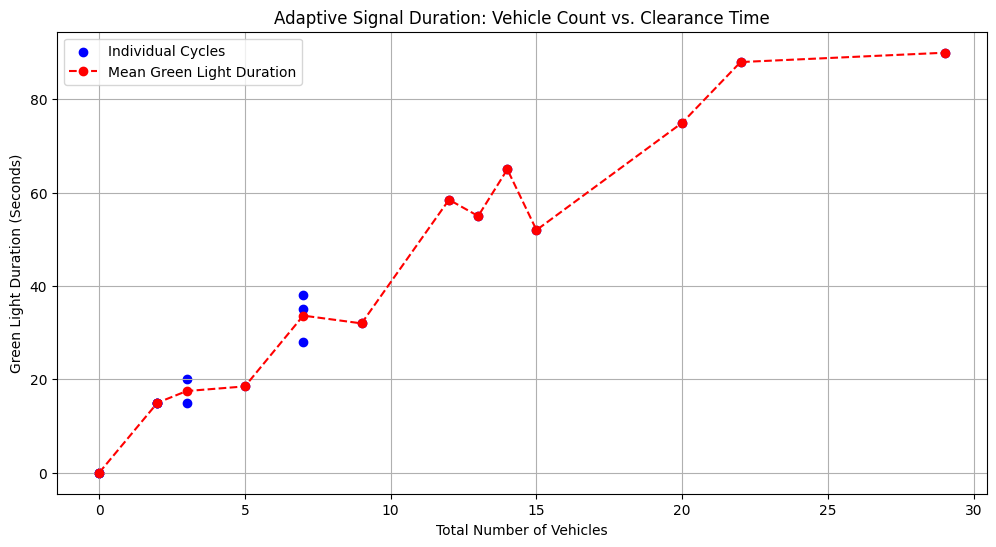

Total Time Saved over 20 Cycles: 1085.0 seconds
Average Time Saved per Cycle: 54.25 seconds


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('traffic_simulation_data.csv')

# 1. Total Vehicles vs Adaptive Time (Proportionality)
df['total_vehicles'] = df['cars'] + df['bikes'] + df['trucks']

# Calculate the mean t_adaptive for each total_vehicles value
mean_adaptive_time = df.groupby('total_vehicles')['t_adaptive'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.scatter(df['total_vehicles'], df['t_adaptive'], color='blue', label='Individual Cycles')
plt.plot(mean_adaptive_time['total_vehicles'], mean_adaptive_time['t_adaptive'], color='red', linestyle='--', marker='o', label='Mean Green Light Duration')
plt.title('Adaptive Signal Duration: Vehicle Count vs. Clearance Time')
plt.xlabel('Total Number of Vehicles')
plt.ylabel('Green Light Duration (Seconds)')
plt.grid(True)
plt.legend()
plt.show()

# 2. Time Saved Analysis (Idle Time)
print("Total Time Saved over 20 Cycles:", df['time_saved'].sum(), "seconds")
print("Average Time Saved per Cycle:", df['time_saved'].mean(), "seconds")

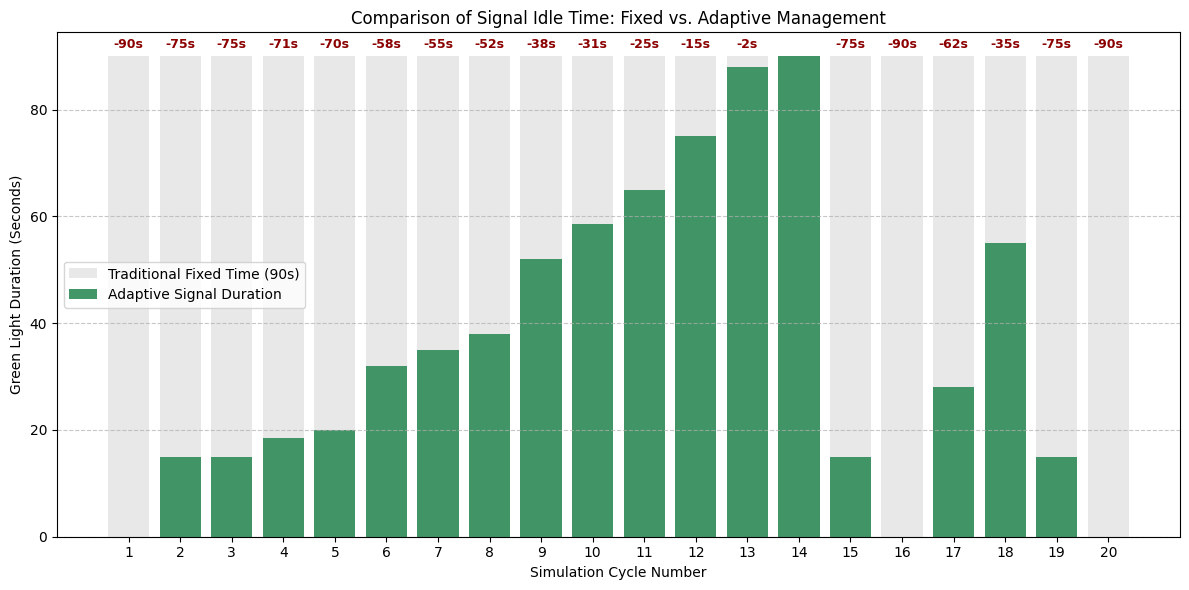

Total Time Saved over 20 Cycles: 1085.0 seconds
Average Efficiency Improvement: 60.28%


In [ ]:
# 1. Load the simulation data
df = pd.read_csv('traffic_simulation_data.csv')

# 2. Setup the visualization
plt.figure(figsize=(12, 6))

# Plot the baseline (Fixed 90s)
plt.bar(df['cycle'], df['t_fixed'], label='Traditional Fixed Time (90s)', color='lightgray', alpha=0.5)

# Plot the Adaptive Duration
plt.bar(df['cycle'], df['t_adaptive'], label='Adaptive Signal Duration', color='seagreen', alpha=0.9)

# Annotate the 'Time Saved' (Red labels)
for i, row in df.iterrows():
    if row['time_saved'] > 0:
        plt.text(row['cycle'], row['t_fixed'] + 1, f"-{int(row['time_saved'])}s",
                 ha='center', va='bottom', color='darkred', fontsize=9, fontweight='bold')

plt.xlabel('Simulation Cycle Number')
plt.ylabel('Green Light Duration (Seconds)')
plt.title('Comparison of Signal Idle Time: Fixed vs. Adaptive Management')
plt.xticks(df['cycle'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Statistical Proof
total_saved = df['time_saved'].sum()
improvement = (total_saved / df['t_fixed'].sum()) * 100
print(f"Total Time Saved over 20 Cycles: {total_saved} seconds")
print(f"Average Efficiency Improvement: {improvement:.2f}%")

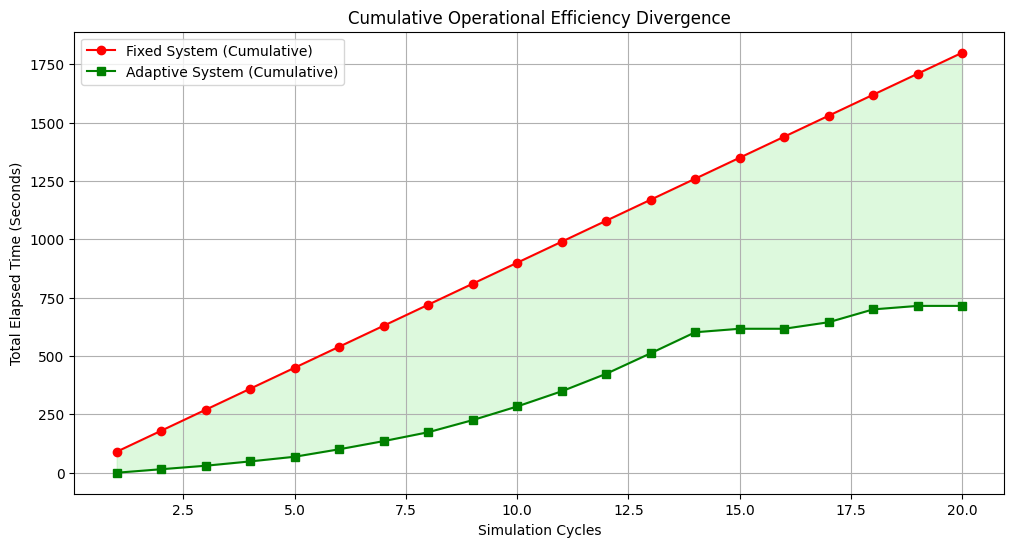

/tmp/ipython-input-3093218721.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['t_fixed'], df['t_adaptive']], labels=['Fixed Timer', 'Adaptive Logic'])


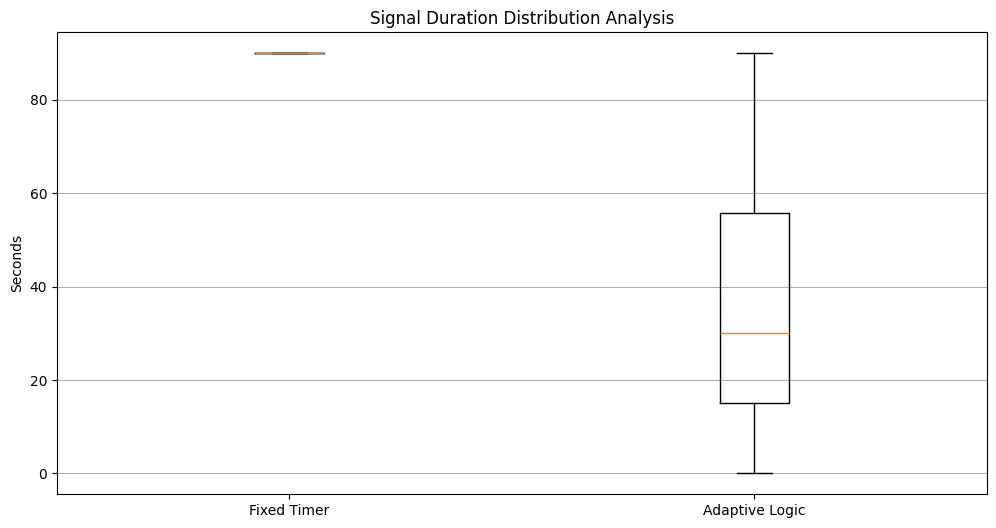

In [ ]:
# --- 1. Cumulative Time Savings Chart ---
df['cum_fixed'] = df['t_fixed'].cumsum()
df['cum_adaptive'] = df['t_adaptive'].cumsum()

plt.figure(figsize=(12,6))
plt.plot(df['cycle'], df['cum_fixed'], label='Fixed System (Cumulative)', color='red', marker='o')
plt.plot(df['cycle'], df['cum_adaptive'], label='Adaptive System (Cumulative)', color='green', marker='s')
plt.fill_between(df['cycle'], df['cum_fixed'], df['cum_adaptive'], color='lightgreen', alpha=0.3)
plt.title('Cumulative Operational Efficiency Divergence')
plt.xlabel('Simulation Cycles')
plt.ylabel('Total Elapsed Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()

# --- 2. Duration Distribution Analysis ---
plt.figure(figsize=(12,6))
plt.boxplot([df['t_fixed'], df['t_adaptive']], labels=['Fixed Timer', 'Adaptive Logic'])
plt.title('Signal Duration Distribution Analysis')
plt.ylabel('Seconds')
plt.grid(axis='y')
plt.show()